In [1]:
data_dir = '/scratch/mjehangir/Glioma_project/severus/severus_out/sv_annotation/'

In [2]:
setwd(data_dir)

In [3]:
library(dplyr)
library(ggplot2)
library(maftools)
library(ComplexHeatmap)
library(clusterProfiler)
library(org.Hs.eg.db) # for human gene annotations

# Load your SV annotation data
sv_data <- read.delim("sv_full_with_samples.tsv", stringsAsFactors = FALSE)

# Example columns:
# CHROM, POS, END, SVTYPE, SnpEff_Annotation, SIMPLE_ANN_Effect, SIMPLE_ANN_Label, SAMPLE, GT



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))




clusterProfiler v4.14.6 Learn more at https://yulab-smu.top/contrib

In [15]:

# Load without headers
sv_data <- read.delim("sv_full_with_samples.tsv", header = TRUE, stringsAsFactors = FALSE)

# Check first rows
head(sv_data)


,CHROM,POS,END,SVTYPE,SnpEff_Effect,SIMPLE_Effect,SIMPLE_Label,SIMPLE_Gene,Sample,Genotype
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,NC_060925.1,296592,.,INS,downstream_gene_variant,-,-,-,6439C,0/1
2,NC_060925.1,305801,.,INS,intron_variant,-,-,-,6266D,0/1
3,NC_060925.1,325206,329019,DEL,intergenic_region,-,-,-,3188,0/1
4,NC_060925.1,364363,.,INS,intron_variant,-,-,-,6478A,0/1
5,NC_060925.1,364364,.,INS,intron_variant,-,-,-,2436A_run5,0/1
6,NC_060925.1,364394,.,INS,intron_variant,-,-,-,6365A,0/1


In [80]:
unique(sv_data$SIMPLE_Label)


[1] "-"               "Exon3del"        "Exon36-38del"    "Exon35-37del"   
  [5] "Exon29-37del"    "Exon34-36del"    "Exon34-42del"    "Exon29-31del"   
  [9] "Exon37-38del"    "Exon36-37del"    "Exon30-37del"    "Exon35-36del"   
 [13] "Exon35-42del"    "Exon30-31del"    "Exon1-2del"      "NOT_PRIORITISED"
 [17] "Exon2del"        "Exon2-3del"      "Exon1del"        "Exon14del"      
 [21] "Exon16del"       "Exon15del"       "Exon67del"       "Exon63del"      
 [25] "Exon65del"       "Exon8-12del"     "Exon7-11del"     "Exon5-9del"     
 [29] "Exon6-10del"     "Exon7del"        "Exon6del"        "Exon5del"       
 [33] "Exon4-5del"      "Exon4del"        "Exon19del"       "Exon3-5del"     
 [37] "Exon2-4del"      "Exon1-4del"      "Exon3-4del"      "Exon9-10del"    
 [41] "Exon3-7del"      "Exon1-7del"      "Exon5-6del"      "Exon6-7del"     
 [45] "Exon7-8del"      "Exon3-30del"     "Exon3-28del"     "Exon2-28del"    
 [49] "Exon2-29del"     "Exon2-26del"     "Exon1-3del"      "Exon8del"       
 [53] "Exon5-8del"      "Exon9del"        "Exon10del"       "Exon13-15del"   
 [57] "Exon13-16del"    "Exon12-15del"    "Exon12-14del"    "Exon13-14del"   
 [61] "Exon3-6del"      "Exon2-5del"      "Exon24-26del"    "Exon22-24del"   
 [65] "Exon23-25del"    "Exon21-23del"    "Exon26-28del"    "Exon25-27del"   
 [69] "Exon20-22del"    "Exon27-29del"    "Exon19-21del"    "Exon15-17del"   
 [73] "Exon4-9del"      "Exon4-10del"     "Exon4-8del"      "Exon17-18del"   
 [77] "Exon19-20del"    "Exon12-13del"    "Exon20del"       "Exon13del"      
 [81] "Exon36del"       "Exon35del"       "Exon37del"       "Exon32del"      
 [85] "Exon11del"       "Exon14-15del"    "Exon15-16del"    "Exon16-17del"   
 [89] "Exon11-12del"    "Exon17del"       "Exon10-11del"    "Exon10-16del"   
 [93] "Exon12-18del"    "Exon14-20del"    "Exon13-19del"    "Exon11-17del"   
 [97] "Exon1-13del"     "Exon7-9del"      "Exon2-6del"      "Exon2-9del"     
[101] "Exon2-8del"      "Exon3-10del"     "Exon23-24del"    "Exon21-22del"   
[105] "Exon22-23del"    "Exon1-8del"      "Exon30-35del"    "Exon31-36del"   
[109] "Exon32-37del"    "Exon26-31del"    "Exon32-35del"    "Exon33-36del"   
[113] "Exon34-37del"    "Exon28-31del"    "Exon21del"       "Exon22del"      
[117] "Exon2-7del"      "Exon3-8del"      "Exon4-30del"     "Exon4-31del"    
[121] "Exon4-27del"     "Exon4-20del"     "Exon4-21del"     "Exon12del"      
[125] "Exon9-12del"     "Exon10-13del"    "Exon8-11del"     "Exon5-7del"     
[129] "Exon6-8del"      "Exon4-6del"      "Exon27-28del"    "Exon16-20del"   
[133] "Exon15-19del"    "Exon4-12del"     "Exon3-11del"

In [207]:
library(dplyr)
library(ggplot2)

sv_data <- sv_data %>%
  mutate(Effect_Class = ifelse(
    grepl("exon|frameshift|missense|stop_gained|splice", SnpEff_Effect, ignore.case = TRUE),
    "Coding",
    "Non-coding"
  ))

df_effect <- sv_data %>%
  count(Effect_Class) %>%
  mutate(
    percent = round(100 * n / sum(n), 1),
    label = paste0(Effect_Class, "\n", percent, "%")
  )

options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 200)

# Plot
p <- ggplot(df_effect, aes(x = "", y = n, fill = Effect_Class)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar(theta = "y") +
  geom_text(aes(label = label), position = position_stack(vjust = 0.5), size = 5) +
  scale_fill_manual(values = c("Coding" = "purple", "Non-coding" = "grey")) +
  theme_void()

# Save as PDF
ggsave("/home/mjehangir/glioma_manuscript/effect_class_piechart.pdf", plot = p, width = 5, height = 5, dpi = 300)


In [208]:
library(dplyr)
library(ggplot2)

# 1. Count how many variants per SnpEff effect
effect_summary <- sv_data %>%
  group_by(SnpEff_Effect) %>%
  summarise(Count = n()) %>%
  ungroup() %>%
  mutate(
    Percent = 100 * Count / sum(Count),
    Label = paste0(SnpEff_Effect, "\n", round(Percent, 2), "%")
  ) %>%
  arrange(desc(Count))

# 2. (Optional) Simplify effect names or group less frequent into "Other"
# For example, keep top 10 and group rest
top_n <- 10
effect_summary <- effect_summary %>%
  mutate(SnpEff_Effect_grouped = ifelse(row_number() <= top_n, SnpEff_Effect, "Other")) %>%
  group_by(SnpEff_Effect_grouped) %>%
  summarise(Count = sum(Count)) %>%
  mutate(
    Percent = 100 * Count / sum(Count),
    Label = paste0(SnpEff_Effect_grouped, "\n", round(Percent, 2), "%")
  )

library(ggplot2)

# Create the plot object
p <- ggplot(effect_summary, aes(x = reorder(SnpEff_Effect_grouped, Count), y = Count, fill = SnpEff_Effect_grouped)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  geom_text(aes(label = paste0(round(Percent, 1), "%")), hjust = -0.1) +
  theme_minimal() +
  labs(
    title = "Overall SV Annotation Distribution (Cohort)",
    x = "SnpEff Effect",
    y = "Variant Count"
  ) +
  theme(legend.position = "none")

# Save the plot to PDF
ggsave("/home/mjehangir/glioma_manuscript/sv_annotation_barplot.pdf", plot = p, width = 7, height = 5, dpi = 300)



In [48]:
head(effect_summary)

SnpEff_Effect_grouped,Count,Percent,Label
<chr>,<int>,<dbl>,<chr>
DOWNSTREAM_GENE_VARIANT,239,3.731460,DOWNSTREAM_GENE_VARIANT 3.73%
EXON_LOSS_VARIANT,1284,20.046838,EXON_LOSS_VARIANT 20.05%
FEATURE_ABLATION,117,1.826698,FEATURE_ABLATION 1.83%
INTERGENIC_REGION,2367,36.955504,INTERGENIC_REGION 36.96%
INTRAGENIC_VARIANT,98,1.530055,INTRAGENIC_VARIANT 1.53%
INTRON_VARIANT,1227,19.156909,INTRON_VARIANT 19.16%


In [209]:
library(dplyr)
library(ggplot2)

# Summarize counts per SIMPLE_Effect
effect_counts <- sv_data %>%
  group_by(SIMPLE_Effect) %>%
  summarise(Count = n()) %>%
  ungroup() %>%
  mutate(
    Percent = 100 * Count / sum(Count),
    Label = paste0(round(Percent, 2), "%")
  ) %>%
  arrange(desc(Count))

library(ggplot2)

# Create the plot
p <- ggplot(effect_counts, aes(x = reorder(SIMPLE_Effect, Count), y = Count, fill = SIMPLE_Effect)) +
  geom_col(show.legend = FALSE) +
  coord_flip() +
  geom_text(aes(label = Label), hjust = -0.1, size = 4) +
  theme_minimal() +
  labs(
    title = "SV Counts per SIMPLE_Effect Annotation",
    x = "SIMPLE Effect",
    y = "Variant Count"
  ) +
  theme(axis.text.y = element_text(size = 10))

# Save as PDF
ggsave("/home/mjehangir/glioma_manuscript/simple_effect_barplot.pdf", plot = p, width = 7, height = 5, dpi = 300)


In [210]:
library(dplyr)
library(ggplot2)
library(readr)

# Load the data
sv_data <- read_tsv("sv_full_with_samples.tsv", col_types = cols())

# Filter valid genes and valid annotations
sv_filtered <- sv_data %>%
  filter(SIMPLE_Gene != "-" & SIMPLE_Gene != "." & SIMPLE_Gene != "NOT_PRIORITISED",
         SIMPLE_Effect != "-" & SIMPLE_Effect != ".")

# Count how many samples per gene and effect type
gene_effect_counts <- sv_filtered %>%
  distinct(SIMPLE_Gene, SIMPLE_Effect, Sample) %>%
  count(SIMPLE_Gene, SIMPLE_Effect, name = "Sample_Count")

# Filter genes affected in ≥ 5 samples (25% of 20)
top_genes <- gene_effect_counts %>%
  group_by(SIMPLE_Gene) %>%
  summarise(Total = sum(Sample_Count)) %>%
  filter(Total >= 5) %>%
  pull(SIMPLE_Gene)

# Subset the data to top genes
gene_effect_counts_filtered <- gene_effect_counts %>%
  filter(SIMPLE_Gene %in% top_genes)

options(repr.plot.width = 8, repr.plot.height = 7, repr.plot.res = 200)

library(ggplot2)

# Create the plot
p <- ggplot(gene_effect_counts_filtered, aes(x = Sample_Count, y = reorder(SIMPLE_Gene, Sample_Count), fill = SIMPLE_Effect)) +
  geom_col() +
  labs(
    title = "Genes Affected by SVs (≥25% of Samples)",
    x = "Number of Samples",
    y = "Gene",
    fill = "SV Annotation Type"
  ) +
  scale_fill_brewer(palette = "Dark2") +
  theme_minimal(base_size = 14)

# Save as PDF
ggsave("/home/mjehangir/glioma_manuscript/genes_affected_by_SVs_barplot.pdf", plot = p, width = 8, height = 6, dpi = 300)


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Genes Affected by SVs (≥25% of Samples)' in 'mbcsToSbcs': >= substituted for ≥ (U+2265)”


In [211]:
head(sv_filtered)

CHROM,POS,END,SVTYPE,SnpEff_Effect,SIMPLE_Effect,SIMPLE_Label,SIMPLE_Gene,Sample,Genotype
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
NC_060925.1,3296065,3297638,DEL,exon_loss_variant,EXON_DEL,Exon3del,LRRC47,6285B,0/1
NC_060925.1,16006072,16022552,DEL,exon_loss_variant,EXON_DEL,Exon36-38del,NBPF1,6439C,0/1
NC_060925.1,16006072,16022552,DEL,exon_loss_variant,EXON_DEL,Exon35-37del,NBPF1,6439C,0/1
NC_060925.1,16006072,16022552,DEL,exon_loss_variant,EXON_DEL,Exon29-37del,NBPF1,6439C,0/1
NC_060925.1,16006072,16022552,DEL,exon_loss_variant,EXON_DEL,Exon35-37del,NBPF1,6439C,0/1
NC_060925.1,16006072,16022552,DEL,exon_loss_variant,EXON_DEL,Exon34-36del,NBPF1,6439C,0/1


In [212]:
sv_filtered[grepl("ADAM12", sv_filtered$SIMPLE_Gene), ]


CHROM,POS,END,SVTYPE,SnpEff_Effect,SIMPLE_Effect,SIMPLE_Label,SIMPLE_Gene,Sample,Genotype
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
NC_060934.1,127164049,127178419,DEL,splice_donor_variant,EXON_DEL,Exon1del,ADAM12,6269C,0/1
NC_060934.1,127164049,127178419,DEL,splice_donor_variant,EXON_DEL,Exon1del,ADAM12,6277A,0/1
NC_060934.1,127164049,127178419,DEL,splice_donor_variant,EXON_DEL,Exon1del,ADAM12,6285B,0/1
NC_060934.1,127164049,127178419,DEL,splice_donor_variant,EXON_DEL,Exon1del,ADAM12,6314E,0/1
NC_060934.1,127164049,127178419,DEL,splice_donor_variant,EXON_DEL,Exon1del,ADAM12,6324B,0/1
NC_060934.1,127164049,127178419,DEL,splice_donor_variant,EXON_DEL,Exon1del,ADAM12,6414C,0/1
NC_060934.1,127164050,127178422,DEL,splice_donor_variant,EXON_DEL,Exon1del,ADAM12,6265D,0/1
NC_060934.1,127164052,127178419,DEL,splice_donor_variant,EXON_DEL,Exon1del,ADAM12,2436A_run3,0/1
NC_060934.1,127164052,127178419,DEL,splice_donor_variant,EXON_DEL,Exon1del,ADAM12,2436A_run5,0/1


In [71]:
library(dplyr)
library(tidyr)
library(ggplot2)

# Filter for entries with valid genes
sv_with_genes <- sv_data %>%
  filter(!is.na(SIMPLE_Gene), SIMPLE_Gene != "-")

# Count SVs per gene per sample
gene_sample_counts <- sv_with_genes %>%
  group_by(Sample, SIMPLE_Gene) %>%
  summarise(SV_Count = n(), .groups = "drop")

# View example (top genes per sample)
head(gene_sample_counts)


Sample,SIMPLE_Gene,SV_Count
<chr>,<chr>,<int>
2436A_run3,ADAM12,1
2436A_run3,ADAM32,12
2436A_run3,ADAM9,7
2436A_run3,AGBL4&AGBL4-IT1,1
2436A_run3,AGBL4-IT1,1
2436A_run3,CFH&CFHR2,1


In [213]:
# Filter top N genes overall to keep plot readable
top_genes <- gene_sample_counts %>%
  group_by(SIMPLE_Gene) %>%
  summarise(Total_SV = sum(SV_Count)) %>%
  arrange(desc(Total_SV)) %>%
  slice_head(n = 50) %>%
  pull(SIMPLE_Gene)

# Filter gene_sample_counts for top genes only
plot_data <- gene_sample_counts %>%
  filter(SIMPLE_Gene %in% top_genes)

options(repr.plot.width = 7, repr.plot.height = 7, repr.plot.res = 200)

# Create the heatmap
p <- ggplot(plot_data, aes(x = Sample, y = reorder(SIMPLE_Gene, -SV_Count), fill = SV_Count)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "grey", high = "red") +
  theme_minimal() +
  labs(
    title = "SV Counts per Gene per Sample (Top 50 Genes)",
    x = "Sample",
    y = "Gene",
    fill = "SV Count"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Save as PDF
ggsave("/home/mjehangir/glioma_manuscript/top50_genes_sv_heatmap.pdf", plot = p, width = 7, height = 7, dpi = 300)


In [75]:
print(top_genes)

 [1] "CELF2"                     "ZAN"                      
 [3] "ST18"                      "ADAM32"                   
 [5] "RPSA2"                     "NALCN"                    
 [7] "ZNF559"                    "SUPT20H"                  
 [9] "NBPF1"                     "ANKS1B"                   
[11] "MPPE1"                     "TACC2"                    
[13] "ADAM9"                     "PRUNE2"                   
[15] "DCLK1"                     "UBE3A"                    
[17] "ARSG"                      "AFF3"                     
[19] "SYNE2"                     "SH3KBP1"                  
[21] "TBATA"                     "PHF20L1"                  
[23] "CABYR"                     "PRKRA"                    
[25] "ZNF559-ZNF177"             "LINGO2"                   
[27] "ATM"                       "MLIP"                     
[29] "RANBP3"                    "TIMELESS"                 
[31] "MUC20"                     "RFC3"                     
[33] "ANKRD36"          

In [78]:
exon_del_genes <- sv_data %>%
  filter(SIMPLE_Effect == "EXON_DEL") %>%
  filter(!is.na(SIMPLE_Gene), SIMPLE_Gene != "-") %>%
  distinct(SIMPLE_Gene) %>%
  arrange(SIMPLE_Gene)

# Print gene names one per line (good for copying)
cat(exon_del_genes$SIMPLE_Gene, sep = "\n")


AARS1
ADAM12
ADAM32
ADAM9
ADAMTSL3
ADGRB3
AFF3
AGBL4-IT1
ANKRD20A2P
ANKRD36
ANKS1B
ARSG
ATM
ATP8B1
BACH2
BPIFA3
BTNL3
CA8
CABYR
CAMK1D
CCDC169-SOHLH2
CELF2
CEP112
CHURC1-FNTB
CPNE8
CREB3L1
CRPPA
CYP4F11
DCLK1
DISP2
DTX1
ELSPBP1
EXOSC6
FMR1
FNTB
GART
HLA-DRB1
HMX3
HOMER3
IMPA2
LCE1D
LCE1E
LIN52
LINC00544
LINC00693
LINC01479
LINC01608
LINC02798
LINGO2
LOC101927189
LOC101929645
LOC105369714
LOC105370563
LOC105370651
LOC105376787
LOC105379278
LOC107987114
LOC107987405
LOC124905679
LOC124906686
LOC124907382
LOC124908007
LOC124908420
LRRC47
LRRC69
MAP2K7
MCF2
MLIP
MLIP-IT1
MPPE1
MUC20
NALCN
NBPF1
NGEF
NPC1
OR4N2
OR52N1
OR56B2P
OSBPL1A
PHF20L1
POTEB2
PPP4C
PRKRA
PRUNE2
PSMC4
PSMD1
PTPN14
PTPRM
RANBP3
RFC3
RFX2
RGS22
RPSA2
SC5D
SH3KBP1
SKAP1
SLC26A7
SMAD4
SMPX
SNX11
SOCS3-DT
SOHLH2
SPADH
SPATA45
SPCS3
ST18
SUPT20H
SYNE2
TACC2
TBATA
TIMELESS
TMTC1
TMTC2
TOX
TSPAN17
UBE3A
VAV2
WIPI1
YEATS4
ZAN
ZNF559
ZNF559-ZNF177
ZNF850


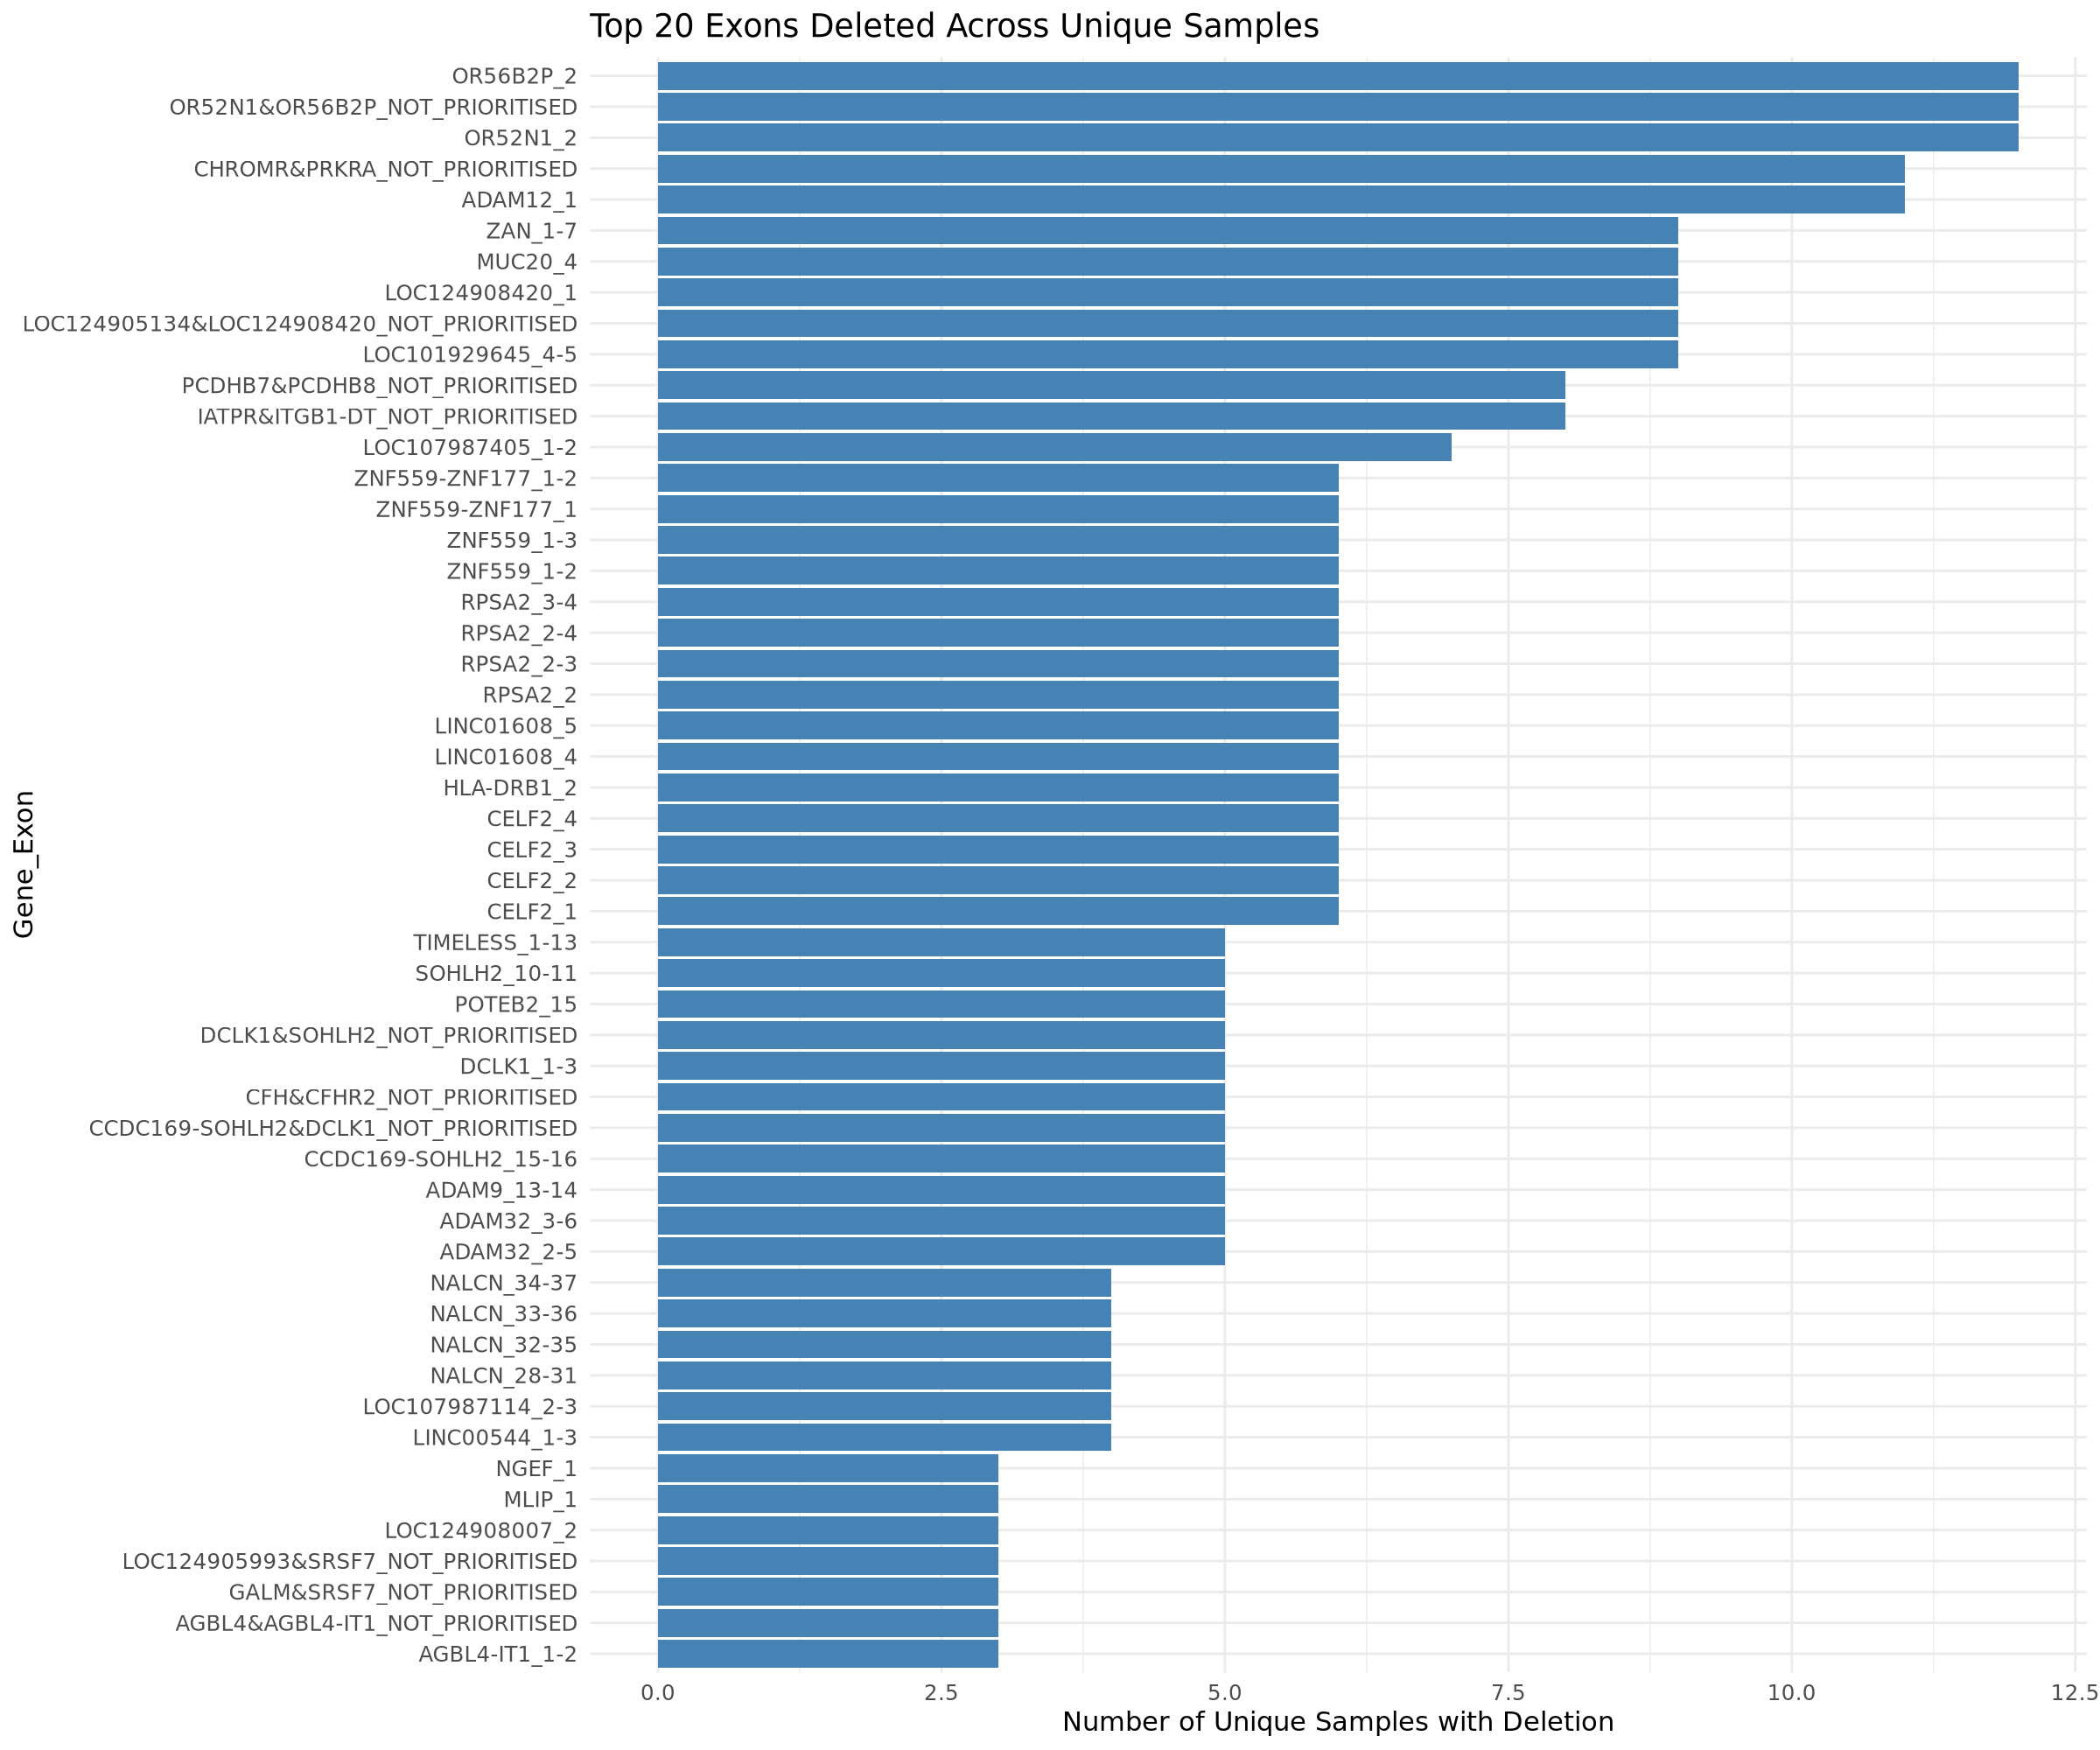

In [144]:
library(dplyr)
library(ggplot2)
library(stringr)

sv_exon_samples <- sv_filtered %>%
  mutate(
    Exon_Raw = str_remove_all(SIMPLE_Label, "Exon|del"),
    Gene_Exon = paste(SIMPLE_Gene, Exon_Raw, sep = "_")
  ) %>%
  group_by(Gene_Exon) %>%
  summarise(
    Unique_Samples = n_distinct(Sample)
  ) %>%
  arrange(desc(Unique_Samples)) %>%
  slice_max(Unique_Samples, n = 50)

# Plotting:
ggplot(sv_exon_samples, aes(x = reorder(Gene_Exon, Unique_Samples), y = Unique_Samples)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Top 20 Exons Deleted Across Unique Samples",
    x = "Gene_Exon",
    y = "Number of Unique Samples with Deletion"
  ) +
  theme_minimal()


In [220]:
library(dplyr)
library(ggplot2)
library(stringr)

# Step 1: Get top 20 genes with the most total deletions
top_genes <- sv_filtered %>%
  mutate(Exon_Clean = str_remove_all(SIMPLE_Label, "Exon|del")) %>%
  count(SIMPLE_Gene, Exon_Clean) %>%
  group_by(SIMPLE_Gene) %>%
  summarise(Total_Deletions = sum(n), .groups = "drop") %>%
  arrange(desc(Total_Deletions)) %>%
  slice_head(n = 20) %>%
  pull(SIMPLE_Gene)

# Step 2: Calculate both sample count and deletion count per exon
sv_exon_both_metrics <- sv_filtered %>%
  mutate(Exon_Clean = str_remove_all(SIMPLE_Label, "Exon|del")) %>%
  filter(SIMPLE_Gene %in% top_genes) %>%
  group_by(SIMPLE_Gene, Exon_Clean) %>%
  summarise(
    Sample_Count = n_distinct(Sample),
    Deletion_Count = n(),
    .groups = "drop"
  )
library(ggplot2)

options(repr.plot.width = 20, repr.plot.height = 15, repr.plot.res = 200)

# Create the plot
p <- ggplot(sv_exon_both_metrics, aes(x = Exon_Clean, y = SIMPLE_Gene)) +
  geom_line(aes(group = SIMPLE_Gene), color = "gray80") +
  geom_point(aes(size = Sample_Count, color = Deletion_Count)) +
  scale_size_continuous(name = "Samples", range = c(2, 8)) +
  scale_color_gradient(name = "Total Deletions", low = "lightblue", high = "darkblue") +
  labs(
    title = "Exon Deletions Across Top 50 Genes",
    x = "Exon Number or Range",
    y = "Gene"
  ) +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 8),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

# Save to PDF
ggsave("/home/mjehangir/glioma_manuscript/exon_deletions_top20_genes.pdf", plot = p, width = 15, height = 8, dpi = 300)


In [172]:
head(sv_exon_both_metrics)

SIMPLE_Gene,Exon_Clean,Sample_Count,Deletion_Count
<chr>,<chr>,<int>,<int>
AARS1,21,2,2
AARS1&EXOSC6,NOT_PRIORITISED,2,2
ADAM12,1,11,11
ADAM32,2-5,5,10
ADAM32,3-6,5,50
ADAM9,13-14,5,35


In [174]:
library(dplyr)
library(stringr)
library(tidyr)

# Split combined gene names like AARS1&EXOSC6 into separate rows
gene_list <- sv_exon_both_metrics %>%
  filter(SIMPLE_Gene != "NOT_PRIORITISED") %>%  # Remove non-informative entries
  separate_rows(SIMPLE_Gene, sep = "&") %>%     # Split by '&'
  distinct(SIMPLE_Gene) %>%                     # Get unique gene names
  pull(SIMPLE_Gene)                             # Extract as vector

# Print or write to a file
print(gene_list)
# writeLines(gene_list, "gene_list_for_enrichr.txt")


  [1] "AARS1"          "EXOSC6"         "ADAM12"         "ADAM32"        
  [5] "ADAM9"          "ADAMTSL3"       "AFF3"           "AGBL4"         
  [9] "AGBL4-IT1"      "ANKRD20A2P"     "ANKRD36"        "ANKS1B"        
 [13] "ARSG"           "ATM"            "ATP8B1"         "ATP8B1-AS1"    
 [17] "BACH2"          "BPIFA3"         "CA8"            "CABYR"         
 [21] "CAMK1D"         "CCDC169-SOHLH2" "DCLK1"          "CELF2"         
 [25] "CFH"            "CFHR2"          "CHROMR"         "PRKRA"         
 [29] "CHURC1-FNTB"    "CRPPA"          "SOHLH2"         "ELSPBP1"       
 [33] "FMR1"           "GALM"           "SRSF7"          "GART"          
 [37] "HLA-DRB1"       "HOMER3"         "IATPR"          "ITGB1-DT"      
 [41] "LIN52"          "LINC00544"      "LINC01608"      "LINGO2"        
 [45] "LOC101929645"   "LOC105369714"   "LOC105379278"   "LOC107987114"  
 [49] "LOC107987405"   "LOC124905134"   "LOC124908420"   "LOC124905993"  
 [53] "LOC124907382"   "LOC124908007" 

In [ ]:
data_dir = '/home/mjehangir/glioma_manuscript/'

In [221]:
sv_exon_samples

Gene_Exon,Unique_Samples
<chr>,<int>
OR52N1&OR56B2P_NOT_PRIORITISED,12
OR52N1_2,12
OR56B2P_2,12
ADAM12_1,11
CHROMR&PRKRA_NOT_PRIORITISED,11
LOC101929645_4-5,9
LOC124905134&LOC124908420_NOT_PRIORITISED,9
LOC124908420_1,9
MUC20_4,9
